In [124]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.decomposition import PCA

# Import models
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor,GradientBoostingRegressor,AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

import optuna

In [14]:
df = pd.read_csv('missing_imputeted_df.csv')
df.head()

,colony,property_type,price_outer,price_per_sqft,Total Floors,Property Age,bedrooms,bathrooms,balconies,built_up_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
0,bhopal,House,105.0,3750,1.0,Old Property,7,5,0,2800.0,0,0,0,0,0,0,1,71,Green View Homes
1,kolar road,Flat,85.0,6508,2.0,New Property,3,3,1,1567.2,0,0,0,1,0,1,1,35,Green View Homes
2,katara hills,Flat,25.0,2173,3.0,New Property,2,2,3,957.0,0,0,0,0,0,0,1,15,Green View Homes
3,aishbagh,House,65.0,5909,2.0,Old Property,4,5,1,2400.0,0,0,0,1,0,0,0,18,Road Facing Homes
4,chuna bhatti,House,650.0,16250,3.0,New Property,6,6,2,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes


In [15]:
# Drop Features that We choose by Feature selection
df.drop(columns=['pooja room', 'view floor plan','study room', 'others','price_per_sqft'],inplace=True)

In [16]:
df['furnishing_type'].value_counts()

furnishing_type
1    1197
0     291
2      78
Name: count, dtype: int64

In [17]:
df['furnishing_type'] = df['furnishing_type'].map({0:"Unfurnished",1:"Semifurnished",2:"furnished"})

<Axes: ylabel='luxury_score'>

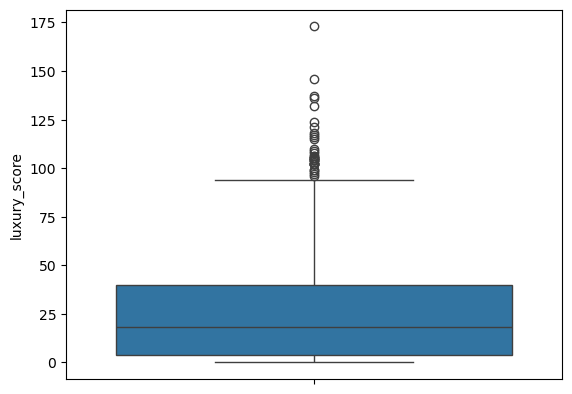

In [18]:
# luxury score
sns.boxplot(df['luxury_score'])

In [19]:
def categorize_luxury(score):
    if 0 <= score < 25:
        return "Low"
    elif 25 <= score < 100:
        return "Medium"
    elif 100 >= 100:
        return "High"

In [21]:
df['luxury_category'] = df['luxury_score'].apply(categorize_luxury)

In [23]:
df.drop(columns=['luxury_score'],inplace=True)

In [24]:
df.head()

,colony,property_type,price_outer,Total Floors,Property Age,bedrooms,bathrooms,balconies,built_up_area,servant room,store room,furnishing_type,Overlooking_Categories,luxury_category
0,bhopal,House,105.0,1.0,Old Property,7,5,0,2800.0,0,0,Semifurnished,Green View Homes,Medium
1,kolar road,Flat,85.0,2.0,New Property,3,3,1,1567.2,0,0,Semifurnished,Green View Homes,Medium
2,katara hills,Flat,25.0,3.0,New Property,2,2,3,957.0,0,0,Semifurnished,Green View Homes,Low
3,aishbagh,House,65.0,2.0,Old Property,4,5,1,2400.0,0,0,Unfurnished,Road Facing Homes,Low
4,chuna bhatti,House,650.0,3.0,New Property,6,6,2,4000.0,1,1,furnished,Road Facing Homes,Low


In [30]:
# Create input and output set
X = df.drop(columns=['price_outer'])
y = df['price_outer']

# Applying the log1p transformation to the target variable
y_transformed = np.log1p(y)

# We Will Try 3 encoding techniques : ordinal encoding , onehotencoding , target encoding on each model

# 1. Ordinal Encoding

In [40]:
columns_to_encode = ['property_type','colony', 'Property Age', 'furnishing_type', 'luxury_category', 'Overlooking_Categories']

In [41]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Total Floors','bedrooms', 'bathrooms', 'balconies','built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode)
    ], 
    remainder='passthrough'
)

In [36]:
X.columns

Index(['colony', 'property_type', 'Total Floors', 'Property Age', 'bedrooms',
       'bathrooms', 'balconies', 'built_up_area', 'servant room', 'store room',
       'furnishing_type', 'Overlooking_Categories', 'luxury_category'],
      dtype='object')

In [42]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [43]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [44]:
scores.mean(),scores.std()

(0.6487010824309223, 0.05814118388951525)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [46]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Total Floors', 'bedrooms',
                                                   'bathrooms', 'balconies',
                                                   'built_up_area',
                                                   'servant room',
                                                   'store room']),
                                                 ('cat', OrdinalEncoder(),
                                                  ['property_type', 'colony',
                                                   'Property Age',
                                                   'furnishing_type',
                                                   'luxury_category',
                                                   'Overlooking_Categories'])])),
                ('regressor', LinearRegression())])

In [47]:
y_pred = pipeline.predict(X_test)

In [48]:
y_pred = np.expm1(y_pred)

In [49]:
mean_absolute_error(np.expm1(y_test),y_pred)

45.227513822846035

In [60]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output

In [61]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [62]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [63]:
model_output

[['linear_reg', 0.6487010824309223, 45.227513822846035],
 ['svr', 0.6781204883302238, 36.684148320912016],
 ['ridge', 0.6487182361890291, 45.234825256613235],
 ['LASSO', -0.011539845690029128, 57.127716943733695],
 ['decision tree', 0.5469481670113538, 41.93957922969654],
 ['random forest', 0.7422313845270768, 31.327299200403584],
 ['extra trees', 0.7325784505129918, 31.23468064223625],
 ['gradient boosting', 0.755426512974703, 31.38374424976966],
 ['adaboost', 0.6664320776374495, 38.635192615555475],
 ['mlp', 0.6654271697191564, 55.67152263871787],
 ['xgboost', 0.7322587847928241, 30.699124291778364]]

In [64]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [65]:
model_df.sort_values(['mae'])

,name,r2,mae
10,xgboost,0.732259,30.699124
6,extra trees,0.732578,31.234681
5,random forest,0.742231,31.327299
7,gradient boosting,0.755427,31.383744
1,svr,0.678120,36.684148
8,adaboost,0.666432,38.635193
4,decision tree,0.546948,41.939579
0,linear_reg,0.648701,45.227514
2,ridge,0.648718,45.234825
9,mlp,0.665427,55.671523


# OneHotEncoding

In [66]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Total Floors','bedrooms', 'bathrooms', 'balconies','built_up_area', 'servant room', 'store room']),
        ('cat', OneHotEncoder(), columns_to_encode)
    ], 
    remainder='passthrough'
)

In [67]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [68]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [69]:
scores.mean(),scores.std()

(0.6902903568242412, 0.06564390809855314)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [72]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Total Floors', 'bedrooms',
                                                   'bathrooms', 'balconies',
                                                   'built_up_area',
                                                   'servant room',
                                                   'store room']),
                                                 ('cat', OneHotEncoder(),
                                                  ['property_type', 'colony',
                                                   'Property Age',
                                                   'furnishing_type',
                                                   'luxury_category',
                                                   'Overlooking_Categories'])])),
                ('regressor', LinearRegression())])

In [73]:
y_pred = pipeline.predict(X_test)

In [74]:
y_pred = np.expm1(y_pred)

In [75]:
mean_absolute_error(np.expm1(y_test),y_pred)

40.68508763749291

In [76]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [77]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [78]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_

In [79]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [80]:
model_df.sort_values(['mae'])

,name,r2,mae
1,svr,0.755074,30.176709
6,extra trees,0.748320,30.502504
5,random forest,0.753707,31.133302
7,gradient boosting,0.760901,31.463160
9,mlp,0.732551,31.484004
10,xgboost,0.737288,31.861625
8,adaboost,0.660695,38.426820
0,linear_reg,0.690290,40.685088
2,ridge,0.691301,40.757250
4,decision tree,0.588188,44.196492


# Target Encoding

In [91]:
X.columns

Index(['colony', 'property_type', 'Total Floors', 'Property Age', 'bedrooms',
       'bathrooms', 'balconies', 'built_up_area', 'servant room', 'store room',
       'furnishing_type', 'Overlooking_Categories', 'luxury_category'],
      dtype='object')

In [108]:
import category_encoders as ce

columns_to_encode = ['property_type','colony', 'Property Age', 'furnishing_type', 'luxury_category', 'Overlooking_Categories']

# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(), ['furnishing_type', 'luxury_category', 'Overlooking_Categories']),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['Property Age','property_type']),
        ('target_enc', ce.TargetEncoder(), ['colony']),
        ('num', StandardScaler(),  ['Total Floors','bedrooms','bathrooms','balconies','built_up_area','servant room','store room'])
    ]
    # remainder='passthrough'
)

In [109]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [110]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [111]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Yogesh\anaconda3\Lib\site-packages\sklearn\neural_network\_

In [112]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [113]:
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.754425,28.748947
5,random forest,0.754986,30.691693
7,gradient boosting,0.758578,31.302990
1,svr,0.743794,31.693624
10,xgboost,0.729703,32.512372
8,adaboost,0.687214,35.952742
9,mlp,0.739782,36.537427
4,decision tree,0.565730,38.707803
0,linear_reg,0.681854,41.734985
2,ridge,0.682120,41.750852


# Extra Tree and random forest performing best , so we will tune this two extra tree and random forest model

# 1. Extra Tree

In [150]:
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns=['price_outer']),df['price_outer'],test_size=0.2,random_state=42)

In [129]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1252, 13), (314, 13), (1252,), (314,))

In [151]:
y_train_log = np.log1p(y_train)

In [132]:

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "max_depth": trial.suggest_int("max_depth", 5, 50),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = ExtraTreesRegressor(**params)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    maes = []
    
    for train_idx, val_idx in cv.split(x_train):
        X_train, X_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
        Y_train, Y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]



        # log transform
        y_train_log = np.log1p(Y_train)

        pipeline.fit(X_train, y_train_log)

        # prediction in log
        y_pred_log = pipeline.predict(X_val)

        # back to original scale
        y_pred = np.expm1(y_pred_log)

        mae = mean_absolute_error(Y_val, y_pred)
        maes.append(mae)

    return np.mean(maes)



In [133]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)


[I 2026-02-06 21:58:07,007] A new study created in memory with name: no-name-140dfbf5-06aa-4e26-9546-d337a1c6c059
[I 2026-02-06 21:58:12,683] Trial 0 finished with value: 35.09985735629152 and parameters: {'n_estimators': 451, 'max_depth': 28, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 35.09985735629152.
[I 2026-02-06 21:58:28,135] Trial 1 finished with value: 38.12882630976343 and parameters: {'n_estimators': 1318, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 35.09985735629152.
[I 2026-02-06 21:58:40,550] Trial 2 finished with value: 33.23432646736306 and parameters: {'n_estimators': 689, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}. Best is trial 2 with value: 33.23432646736306.
[I 2026-02-06 21:59:03,148] Trial 3 finished with value: 38.106940597412496 and pa

In [134]:
print("Best MAE:", study.best_value)
print("Best Params:", study.best_params)

Best MAE: 32.73075467371915
Best Params: {'n_estimators': 1645, 'max_depth': 38, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}


In [141]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(), ['furnishing_type', 'luxury_category', 'Overlooking_Categories']),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['Property Age','property_type']),
        ('target_enc', ce.TargetEncoder(), ['colony']),
        ('num', StandardScaler(),  ['Total Floors','bedrooms','bathrooms','balconies','built_up_area','servant room','store room'])
    ]
    # remainder='passthrough'
)

# model with best params on test data
best_params = study.best_params
model = ExtraTreesRegressor(**best_params)

x_train_trans = preprocessor.fit_transform(x_train,y_train)
x_test_trans = preprocessor.transform(x_test)
y_train_trans = np.log1p(y_train)

model.fit(x_train_trans,y_train_trans)
y_pred = model.predict(x_test_trans)
y_pred_norm = np.expm1(y_pred)
print(f"MAE On Test {mean_absolute_error(y_test,y_pred_norm)}")

MAE On Test 29.11925281169546


# 2. Random Forest

In [142]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error


def objective_rf(trial):

    params = {
        # Core
        "n_estimators": trial.suggest_int("n_estimators", 100, 2000),
        "max_depth": trial.suggest_int("max_depth", 2, 20),

        # Split control
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),

        # Feature sampling
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),

        # Overfitting control
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 10, 300),
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 0.0, 0.02),

        # Randomness / regularization
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "oob_score": trial.suggest_categorical("oob_score", [True, False]),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.05),

        # Performance
        "random_state": 42,
        "n_jobs": -1
    }

    # ⚠️ oob_score only works if bootstrap=True
    if params["bootstrap"] == False:
        params["oob_score"] = False

    model = RandomForestRegressor(**params)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    maes = []

    for train_idx, val_idx in cv.split(x_train):
        X_train, X_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
        Y_train, Y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # log transform
        y_train_log = np.log1p(Y_train)

        pipeline.fit(X_train, y_train_log)

        # prediction in log
        y_pred_log = pipeline.predict(X_val)

        # back to original scale
        y_pred = np.expm1(y_pred_log)

        mae = mean_absolute_error(Y_val, y_pred)
        maes.append(mae)

    return np.mean(maes)


In [143]:
study = optuna.create_study(direction="minimize")
study.optimize(objective_rf, n_trials=50)


[I 2026-02-06 22:32:11,962] A new study created in memory with name: no-name-2bdc50a4-9e5d-4294-9e51-64a84d2c25bb
[I 2026-02-06 22:32:54,946] Trial 0 finished with value: 41.935973094105734 and parameters: {'n_estimators': 1980, 'max_depth': 5, 'min_samples_split': 29, 'min_samples_leaf': 7, 'max_features': None, 'max_leaf_nodes': 54, 'min_impurity_decrease': 0.014205363435671225, 'bootstrap': True, 'oob_score': True, 'ccp_alpha': 0.039347214172049456}. Best is trial 0 with value: 41.935973094105734.
[I 2026-02-06 22:33:13,833] Trial 1 finished with value: 41.966538525696556 and parameters: {'n_estimators': 882, 'max_depth': 20, 'min_samples_split': 26, 'min_samples_leaf': 3, 'max_features': None, 'max_leaf_nodes': 213, 'min_impurity_decrease': 0.006463988365863496, 'bootstrap': True, 'oob_score': True, 'ccp_alpha': 0.0401079502370393}. Best is trial 0 with value: 41.935973094105734.
[I 2026-02-06 22:33:17,946] Trial 2 finished with value: 44.18492233669121 and parameters: {'n_estimato

In [144]:
print("Best MAE:", study.best_value)
print("Best Params:", study.best_params)

Best MAE: 34.03872727983948
Best Params: {'n_estimators': 1652, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': None, 'max_leaf_nodes': 247, 'min_impurity_decrease': 0.0008887971809255941, 'bootstrap': True, 'oob_score': True, 'ccp_alpha': 0.001848267390945942}


In [145]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(), ['furnishing_type', 'luxury_category', 'Overlooking_Categories']),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['Property Age','property_type']),
        ('target_enc', ce.TargetEncoder(), ['colony']),
        ('num', StandardScaler(),  ['Total Floors','bedrooms','bathrooms','balconies','built_up_area','servant room','store room'])
    ]
    # remainder='passthrough'
)

# model with best params on test data
best_params = study.best_params
model = RandomForestRegressor(**best_params)

x_train_trans = preprocessor.fit_transform(x_train,y_train)
x_test_trans = preprocessor.transform(x_test)
y_train_trans = np.log1p(y_train)

model.fit(x_train_trans,y_train_trans)
y_pred = model.predict(x_test_trans)
y_pred_norm = np.expm1(y_pred)
print(f"MAE On Test {mean_absolute_error(y_test,y_pred_norm)}")

MAE On Test 32.4346858130244


# 3. XGBoost

In [146]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error


def objective_xgb(trial):

    params = {
        # boosting core
        "n_estimators": trial.suggest_int("n_estimators", 300, 4000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),

        # tree structure
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 30, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 10.0),

        # sampling (very important)
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 1.0),

        # regularization
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 50.0, log=True),

        # XGB-specific
        "tree_method": "hist",   # fast
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    maes = []

    for train_idx, val_idx in cv.split(x_train):
        X_train, X_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
        Y_train, Y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # log transform
        y_train_log = np.log1p(Y_train)

        pipeline.fit(X_train, y_train_log)

        # predict in log
        y_pred_log = pipeline.predict(X_val)

        # back to original scale
        y_pred = np.expm1(y_pred_log)

        mae = mean_absolute_error(Y_val, y_pred)
        maes.append(mae)

    return np.mean(maes)


In [147]:
study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=50)

print("Best MAE:", study_xgb.best_value)
print("Best Params:", study_xgb.best_params)


[I 2026-02-06 23:08:41,835] A new study created in memory with name: no-name-418282cf-7afe-4ad7-a197-662b205aae38
[I 2026-02-06 23:08:46,528] Trial 0 finished with value: 34.383119369565804 and parameters: {'n_estimators': 3021, 'learning_rate': 0.023684030412844427, 'max_depth': 4, 'min_child_weight': 26.681393126246746, 'gamma': 2.1551544144426718, 'subsample': 0.856763443472918, 'colsample_bytree': 0.8614243402316472, 'colsample_bylevel': 0.8153004658359744, 'colsample_bynode': 0.7129474729111964, 'reg_alpha': 0.001286514683011624, 'reg_lambda': 0.00020438416486170968}. Best is trial 0 with value: 34.383119369565804.
[I 2026-02-06 23:08:48,735] Trial 1 finished with value: 34.33018367360149 and parameters: {'n_estimators': 1406, 'learning_rate': 0.10155316271178577, 'max_depth': 11, 'min_child_weight': 6.222280266353237, 'gamma': 2.23082872604335, 'subsample': 0.7387054612866398, 'colsample_bytree': 0.6693155439830858, 'colsample_bylevel': 0.5369699010909851, 'colsample_bynode': 0.9

Best MAE: 31.87889659951503
Best Params: {'n_estimators': 3676, 'learning_rate': 0.00716213745666591, 'max_depth': 6, 'min_child_weight': 2.9053336847229865, 'gamma': 0.08546609194488722, 'subsample': 0.8373913895118874, 'colsample_bytree': 0.8040704350706257, 'colsample_bylevel': 0.8319927906927926, 'colsample_bynode': 0.7840668788890185, 'reg_alpha': 3.3982861482232007e-07, 'reg_lambda': 0.3196542120698139}


In [148]:
print("Best MAE:", study_xgb.best_value)
print("Best Params:", study_xgb.best_params)


Best MAE: 31.87889659951503
Best Params: {'n_estimators': 3676, 'learning_rate': 0.00716213745666591, 'max_depth': 6, 'min_child_weight': 2.9053336847229865, 'gamma': 0.08546609194488722, 'subsample': 0.8373913895118874, 'colsample_bytree': 0.8040704350706257, 'colsample_bylevel': 0.8319927906927926, 'colsample_bynode': 0.7840668788890185, 'reg_alpha': 3.3982861482232007e-07, 'reg_lambda': 0.3196542120698139}


In [149]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(), ['furnishing_type', 'luxury_category', 'Overlooking_Categories']),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['Property Age','property_type']),
        ('target_enc', ce.TargetEncoder(), ['colony']),
        ('num', StandardScaler(),  ['Total Floors','bedrooms','bathrooms','balconies','built_up_area','servant room','store room'])
    ]
    # remainder='passthrough'
)

# model with best params on test data
best_params = study.best_params
model = XGBRegressor(**best_params)

x_train_trans = preprocessor.fit_transform(x_train,y_train)
x_test_trans = preprocessor.transform(x_test)
y_train_trans = np.log1p(y_train)

model.fit(x_train_trans,y_train_trans)
y_pred = model.predict(x_test_trans)
y_pred_norm = np.expm1(y_pred)
print(f"MAE On Test {mean_absolute_error(y_test,y_pred_norm)}")

C:\Users\Yogesh\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:21:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "bootstrap", "ccp_alpha", "max_leaf_nodes", "min_impurity_decrease", "min_samples_leaf", "min_samples_split", "oob_score" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAE On Test 33.49653151858385


# out of these 3 Extra is best.

In [152]:
# save extra tree model with best params
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(), ['furnishing_type', 'luxury_category', 'Overlooking_Categories']),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['Property Age','property_type']),
        ('target_enc', ce.TargetEncoder(), ['colony']),
        ('num', StandardScaler(),  ['Total Floors','bedrooms','bathrooms','balconies','built_up_area','servant room','store room'])
    ]
    # remainder='passthrough'
)

et_params = {'n_estimators': 1645, 'max_depth': 38, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}
pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", ExtraTreesRegressor(**et_params) )
    ])

pipeline.fit(x_train,y_train_log)
y_pred = pipeline.predict(x_test)
y_pred_norm = np.expm1(y_pred)
print(f"MAE On Test {mean_absolute_error(y_test,y_pred_norm)}")

MAE On Test 29.000225736365913


In [153]:
import joblib
joblib.dump(pipeline,'pipeline.joblib')

['pipeline.joblib']

In [155]:
!python -c "import sklearn; print(sklearn.__version__)"


1.6.1


In [ ]:
pip install scikit-learn==1.6.1